In [65]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# ==========================================================
# 1. LOAD OPTIMAL PARAMETERS
# ==========================================================
with open('../results/optimal_params.json', 'r') as f:
    optimal_params = json.load(f)

gamma_oos = optimal_params['gamma']
kappa_oos = optimal_params['kappa']

print(f"Loaded Parameters -> Gamma: {gamma_oos:.6f} | Kappa: {kappa_oos:.4f}")
print(f"Train Sharpe was: {optimal_params['train_sharpe']:.3f}")

# ==========================================================
# 2. LOAD DATA — VARIANCE ON LEVEL (SAME AS NB03)
# ==========================================================
df = pd.read_csv('../data/strategy_results.csv', index_col=0, parse_dates=True)
df = df.rename(columns={'spread': 'spread_kalman', 'beta': 'beta_kalman'})
df = df.dropna().copy()

# MUST match NB03: variance on LEVEL, not diff
df['variance'] = df['spread_kalman'].rolling(window=120).var()
df['variance'] = df['variance'].shift(1)
df['variance'] = df['variance'].bfill() 
df.loc[df['variance'] <= 0, 'variance'] = 1e-8

# ==========================================================
# 3. ISOLATE OUT-OF-SAMPLE DATA
# ==========================================================
df_test = df[df.index >= '2024-01-01'].copy()

# Remove rows where the next bar is >2 minutes away (gaps in data)
# These create phantom fills because the spread "jumps" over our quotes
time_diff = df_test.index.to_series().diff()
gap_mask = time_diff > pd.Timedelta(minutes=2)
print(f"Bars after gaps >2min: {gap_mask.sum()} ({gap_mask.sum()/len(df_test)*100:.1f}%)")
df_test['has_gap'] = gap_mask.values

print(f"OOS Test Set: {len(df_test)} rows from {df_test.index[0].date()} to {df_test.index[-1].date()}")

Loaded Parameters -> Gamma: 0.084026 | Kappa: 0.7284
Train Sharpe was: 1.447
Bars after gaps >2min: 2688 (1.2%)
OOS Test Set: 217229 rows from 2024-01-02 to 2026-03-20


In [68]:
# ==============================================================================
# OOS SIMULATION ENGINE (ALL FIXES)
# ==============================================================================

class AsymptoticMarketMaker:
    def __init__(self, gamma, kappa, max_inventory=50):
        self.gamma = gamma          
        self.kappa = kappa          
        self.max_inventory = max_inventory
        self.q = 0                  
        
    def get_quotes(self, mid_price, variance, min_profitable_delta):
        r = mid_price - (self.q * self.gamma * variance)
        
        liquidity_premium = (1 / self.gamma) * np.log(1 + (self.gamma / self.kappa))
        risk_premium = 0.5 * self.gamma * variance
        as_delta = liquidity_premium + risk_premium
        
        delta = max(as_delta, min_profitable_delta)
        
        bid = r - delta
        ask = r + delta
        
        if self.q >= self.max_inventory:
            bid = -np.inf
        elif self.q <= -self.max_inventory:
            ask = np.inf
            
        return bid, ask, r, as_delta  # return as_delta for diagnostics

def run_oos_backtest(data_slice, gamma_val, kappa_val, max_inv=50):
    agent = AsymptoticMarketMaker(gamma=gamma_val, kappa=kappa_val, max_inventory=max_inv)
    cash = 0.0
    
    contract_multiplier = 100 
    alpaca_fee_per_share = 0.005 
    minimum_pure_profit = 0.005
    
    spread_kalman = data_slice['spread_kalman'].values
    variance = data_slice['variance'].values
    beta_kalman = data_slice['beta_kalman'].values
    dates = data_slice.index.date
    
    # Detect time gaps — bars >2min apart are not truly consecutive
    time_diffs = pd.Series(data_slice.index).diff()
    has_gap = (time_diffs > pd.Timedelta(minutes=2)).values
    
    n = len(data_slice)
    equity_curve = np.zeros(n)
    inventory_hist = np.zeros(n)
    fills = 0
    eod_liquidations = 0
    phantom_skips = 0
    as_deltas = []
    fee_floors = []
    
    for i in range(n - 1):
            total_physical_shares = contract_multiplier + (contract_multiplier * beta_kalman[i])
            real_commission = total_physical_shares * alpaca_fee_per_share
            
            commission_per_spread_unit = real_commission / contract_multiplier
            min_profitable_delta = commission_per_spread_unit + minimum_pure_profit
            
            bid, ask, r, as_delta = agent.get_quotes(spread_kalman[i], variance[i], min_profitable_delta)
            next_sync_price = spread_kalman[i+1]
            
            as_deltas.append(as_delta)
            fee_floors.append(min_profitable_delta)
            
            # END OF DAY LIQUIDATION
            if dates[i] != dates[i+1]:
                if agent.q != 0:
                    liquidation_value = agent.q * next_sync_price * contract_multiplier
                    liquidation_cost = real_commission * abs(agent.q)
                    cash += liquidation_value - liquidation_cost
                    eod_liquidations += 1
                    agent.q = 0
                    
            # SKIP if next bar is after a time gap (phantom fill prevention)
            elif has_gap[i+1]:
                phantom_skips += 1
                
            else:
                # NORMAL INTRADAY EXECUTION
                if next_sync_price <= bid and agent.q < agent.max_inventory and bid != -np.inf:
                    agent.q += 1
                    cash -= (bid * contract_multiplier) + real_commission
                    fills += 1
                    
                elif next_sync_price >= ask and agent.q > -agent.max_inventory and ask != np.inf:
                    agent.q -= 1
                    cash += (ask * contract_multiplier) - real_commission
                    fills += 1
                
            equity_curve[i+1] = cash + (agent.q * next_sync_price * contract_multiplier)
            inventory_hist[i+1] = agent.q
            
    equity_series = pd.Series(equity_curve, index=data_slice.index)
    inventory_series = pd.Series(inventory_hist, index=data_slice.index)
    
    diagnostics = {
            'fills': fills,
            'eod_liquidations': eod_liquidations,
            'phantom_skips': phantom_skips,
            'as_delta_mean': np.mean(as_deltas),
            'as_delta_std': np.std(as_deltas),
            'fee_floor_mean': np.mean(fee_floors),
            'pct_model_active': np.mean([a > f for a, f in zip(as_deltas, fee_floors)]) * 100,
        }
    
    return equity_series, inventory_series, diagnostics

In [69]:
# ==========================================================
# RUN FINAL OUT-OF-SAMPLE BACKTEST
# ==========================================================
print("Running Out-Of-Sample Backtest (All Fixes Applied)...")

oos_equity_series, inventory_series, diagnostics = run_oos_backtest(df_test, gamma_oos, kappa_oos)

# Metrics
initial_capital = 100_000.0
oos_equity_series = oos_equity_series + initial_capital

daily_pnl = oos_equity_series.resample('B').last().diff().dropna()
total_net_profit = oos_equity_series.iloc[-1] - initial_capital
return_pct = (total_net_profit / initial_capital) * 100

std_dev = daily_pnl.std()
sharpe_ratio = (daily_pnl.mean() / std_dev) * np.sqrt(252) if std_dev > 0 else 0.0

running_max = oos_equity_series.cummax()
drawdown = (oos_equity_series - running_max) / running_max
max_drawdown = drawdown.min() * 100

print("\n" + "="*55)
print("OUT-OF-SAMPLE PERFORMANCE (2024+)")
print("="*55)
print(f"Total Net Profit:     ${total_net_profit:,.2f} ({return_pct:.2f}%)")
print(f"Sharpe Ratio:         {sharpe_ratio:.3f}")
print(f"Max Drawdown:         {max_drawdown:.2f}%")
print(f"Total Fills:          {diagnostics['fills']:,}")
print(f"Phantom Skips:        {diagnostics['phantom_skips']}")
print(f"EOD Liquidations:     {diagnostics['eod_liquidations']}")
print(f"\n--- AS MODEL HEALTH ---")
print(f"Avg AS Delta:         {diagnostics['as_delta_mean']:.6f}")
print(f"Avg Fee Floor:        {diagnostics['fee_floor_mean']:.6f}")
print(f"Model Active:         {diagnostics['pct_model_active']:.1f}% of bars (AS > fee floor)")
print("="*55)

Running Out-Of-Sample Backtest (All Fixes Applied)...

OUT-OF-SAMPLE PERFORMANCE (2024+)
Total Net Profit:     $4,869.57 (4.87%)
Sharpe Ratio:         1.212
Max Drawdown:         -2.49%
Total Fills:          266
Phantom Skips:        2130
EOD Liquidations:     113

--- AS MODEL HEALTH ---
Avg AS Delta:         1.302718
Avg Fee Floor:        0.025325
Model Active:         100.0% of bars (AS > fee floor)


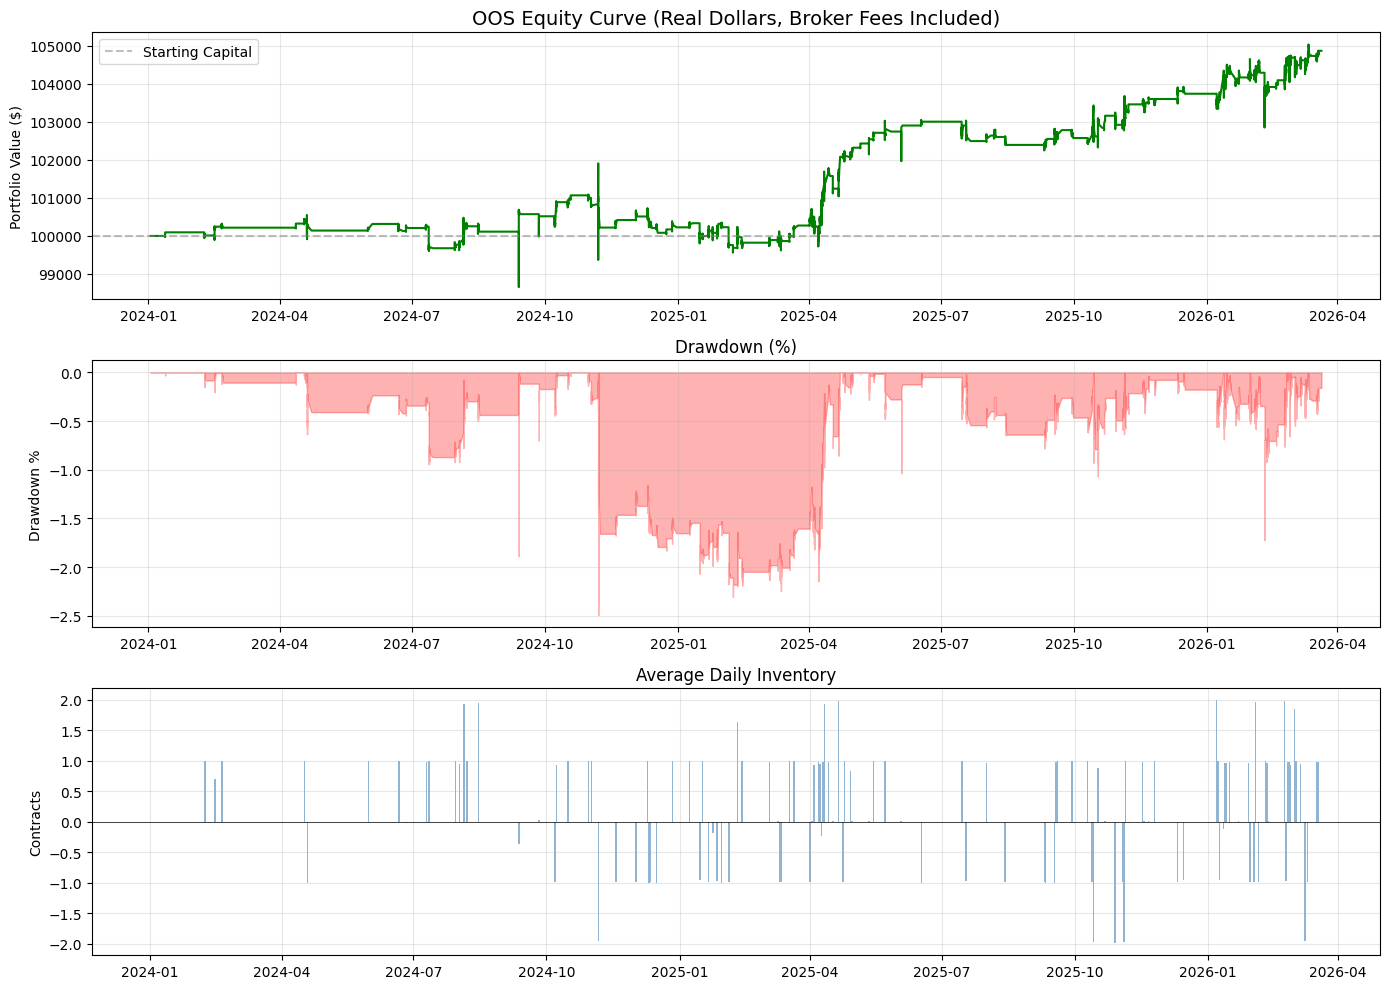

In [70]:
# ==========================================================
# PLOTS
# ==========================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Equity Curve
axes[0].plot(oos_equity_series.index, oos_equity_series, color='green', linewidth=1.5)
axes[0].axhline(initial_capital, color='gray', linestyle='--', alpha=0.5, label='Starting Capital')
axes[0].set_title('OOS Equity Curve (Real Dollars, Broker Fees Included)', fontsize=14)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Drawdown
axes[1].fill_between(drawdown.index, 0, drawdown * 100, color='red', alpha=0.3)
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown %')
axes[1].grid(True, alpha=0.3)

# 3. Inventory Over Time (sampled for visibility)
inv_daily = inventory_series.resample('B').mean()
axes[2].bar(inv_daily.index, inv_daily.values, color='steelblue', alpha=0.6, width=1)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Average Daily Inventory')
axes[2].set_ylabel('Contracts')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/04_oos_performance.png', dpi=150)
plt.show()

In [71]:
# ==========================================================
# SAVE FINAL RESULTS
# ==========================================================
final_results = {
    'total_net_profit': total_net_profit,
    'return_pct': return_pct,
    'sharpe_ratio': sharpe_ratio,
    'max_drawdown_pct': max_drawdown,
    'total_fills': diagnostics['fills'],
    'eod_liquidations': diagnostics['eod_liquidations'],
    'model_active_pct': diagnostics['pct_model_active'],
    'gamma': gamma_oos,
    'kappa': kappa_oos,
}

with open('../results/oos_results.json', 'w') as f:
    json.dump(final_results, f, indent=4)

print("Results saved to ../results/oos_results.json")
print("\nBACKTEST COMPLETE")

Results saved to ../results/oos_results.json

BACKTEST COMPLETE
